# this tutorial demonstrates the use of SWITCH and BRIDGE methods starting with PCC matrices of 2 NB cancer stages

### SWITCH

In [21]:
import pandas as pd
import numpy as np
from igraph import Graph

import data of the format of PCC matrices

In [38]:
# import PCC data
pcc_I = pd.read_csv("/home/jovyan/work/results/Cell/pcc_I.csv", index_col=0)
pcc_IV = pd.read_csv("/home/jovyan/work/results/Cell/pcc_IV.csv", index_col=0)
pcc_I

,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,1.000000,0.107186,0.003285,0.056567,0.317440,-0.184316,0.232333,0.099596,0.456284,0.262566,...,0.106963,0.174599,0.406201,0.212918,0.311296,0.217858,-0.044665,-0.353127,0.266048,-0.570060
DPM1,0.107186,1.000000,0.146014,0.668884,0.192856,-0.057535,0.183870,0.307373,0.125525,-0.467344,...,0.373399,-0.145764,0.375997,0.157474,0.359392,0.106671,-0.121857,-0.158947,0.336275,-0.276111
SCYL3,0.003285,0.146014,1.000000,0.301869,0.060579,0.239397,0.383222,0.271843,-0.092319,0.110659,...,0.334772,0.391966,-0.004672,-0.089531,0.586056,-0.120515,0.157024,0.482084,0.050174,-0.161069
C1orf112,0.056567,0.668884,0.301869,1.000000,0.119165,0.079607,0.208753,0.467044,-0.127322,-0.500644,...,0.457160,-0.127950,0.186204,0.126519,0.305876,-0.187052,0.017256,0.097902,0.069377,-0.371049
FGR,0.317440,0.192856,0.060579,0.119165,1.000000,-0.393483,0.166816,0.120979,0.398055,0.233847,...,0.366609,0.478241,0.721978,0.716994,0.522844,0.349946,-0.221204,-0.165732,0.535570,-0.199934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,0.217858,0.106671,-0.120515,-0.187052,0.349946,-0.497622,-0.261921,-0.372023,0.641458,0.478874,...,-0.032025,0.329933,0.388886,-0.044108,0.191549,1.000000,-0.691101,-0.604141,0.744366,-0.058452
CYB561D2,-0.044665,-0.121857,0.157024,0.017256,-0.221204,0.655300,0.315638,0.286086,-0.281936,-0.098861,...,0.108694,-0.023297,-0.127174,0.038020,-0.084974,-0.691101,1.000000,0.545011,-0.648629,0.096816
CCDC7,-0.353127,-0.158947,0.482084,0.097902,-0.165732,0.596642,0.267250,0.376546,-0.450070,-0.070536,...,0.318949,0.213623,-0.172701,0.019423,0.122841,-0.604141,0.545011,1.000000,-0.482713,0.269748


In [39]:
pcc_I.name = "pcc_I"
pcc_IV.name = "pcc_IV"

import the functions

In [65]:
import sys
sys.path.append('/home/jovyan/work/FUNCTIONS/')
from SWITCH import Reciprocal_SWITCH_pcc_to_distance  # preprocessing step of SWITCH to transform pcc to distances
from SWITCH import distance_to_module_nlog, module_to_json  # transformation step of SWITCH to transform distances to relations for Leiden clustering
from SWITCH import module_to_dict
from BRIDGE import module_relation_bipartite
from BRIDGE import find_all_transition_set
from BRIDGE import file_to_string, find_targets

In [5]:
%pwd
%cd data
%pwd

/home/jovyan/work/tutorial/data


'/home/jovyan/work/tutorial/data'

In [40]:
distance_I = Reciprocal_SWITCH_pcc_to_distance(pcc_matrix=pcc_I, fig_path1="./figures/degree_distribution_III.svg", fig_path2="./figures/distance_distribution_III.svg", fig_path3="./figures/weight_distribution_I.svg", pcc_threshold=0.7)
distance_I.to_csv("distance_I.csv")
distance_I

/home/jovyan/work/FUNCTIONS/methods.py:383: RuntimeWarning: divide by zero encountered in divide
  reciprocal = 1 / non_negative_normalized_pcc


IGRAPH UNW- 12939 1215109 -- 
+ attr: name (v), weight (e)
graph is connected: False
All Pairs Distances:
<class 'list'>
12939X12939
Number of vertices in largest connected component: 12515
Number of edges in largest connected component: 1215099


Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,LINC01176,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.000000,20.911603,20.239683,19.481403,15.602511,18.975504,14.176595,14.485504,22.848814,23.529936,...,21.387527,29.758635,15.348049,15.659967,20.496092,18.243819,20.138413,17.118330,20.038849,15.245633
DPM1,20.911603,0.000000,15.117183,7.310219,17.119149,13.556946,12.694354,13.703895,14.181677,14.088975,...,12.533799,30.692454,18.038975,18.261463,15.180190,10.480387,14.226518,11.682629,10.505642,14.689720
SCYL3,20.239683,15.117183,0.000000,12.075571,17.603856,11.941674,11.545974,11.062483,15.856652,16.005796,...,13.144798,25.715961,18.058372,18.313788,14.206323,10.489183,14.219663,10.293315,12.648229,16.717492
C1orf112,19.481403,7.310219,12.075571,0.000000,14.304198,10.450850,10.114902,9.075106,11.140107,10.525579,...,8.197654,27.129057,14.691442,13.043353,12.860972,7.585451,11.642147,9.164697,10.675150,12.471976
FGR,15.602511,17.119149,17.603856,14.304198,0.000000,12.660762,13.937843,15.581417,10.727827,13.105925,...,16.356970,19.114023,3.960275,3.715291,11.181141,7.508877,11.798881,12.263623,8.618284,15.714399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,18.243819,10.480387,10.489183,7.585451,7.508877,6.663897,9.695020,9.361808,5.843828,8.784327,...,10.931242,21.566562,7.963393,9.627306,14.122562,0.000000,5.303265,5.328395,3.688096,9.499866
CYB561D2,20.138413,14.226518,14.219663,11.642147,11.798881,7.621044,12.193787,12.126386,10.899229,12.968314,...,14.893704,25.750549,12.253397,13.917310,18.029484,5.303265,0.000000,8.246326,5.856451,11.811616
CCDC7,17.118330,11.682629,10.293315,9.164697,12.263623,5.082692,9.424819,8.697745,10.400153,13.016095,...,11.531276,23.905487,12.718139,14.382051,14.163522,5.328395,8.246326,0.000000,6.469684,9.877919


In [7]:
distance_IV = Reciprocal_SWITCH_pcc_to_distance(pcc_matrix=pcc_IV, fig_path1="./figures/degree_distribution_IV.svg", fig_path2="./figures/distance_distribution_IV.svg", fig_path3="./figures/weight_distribution_IV.svg", pcc_threshold=0.7)
distance_IV.to_csv("distance_IV.csv")
distance_IV

/home/jovyan/work/FUNCTIONS/methods.py:383: RuntimeWarning: divide by zero encountered in divide
  reciprocal = 1 / non_negative_normalized_pcc


IGRAPH UNW- 12939 2022063 -- 
+ attr: name (v), weight (e)
graph is connected: False
All Pairs Distances:
<class 'list'>
12939X12939


IOStream.flush timed out


Number of vertices in largest connected component: 12677
Number of edges in largest connected component: 2022053


Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,LAS1L,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Symbol,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.000000,12.560726,10.526023,11.454339,15.958799,14.464694,12.612379,9.221837,21.725939,10.801749,...,14.113409,11.510321,18.498227,18.188342,12.206228,11.631616,10.095812,19.840402,12.717575,5.747060
DPM1,12.560726,0.000000,12.369782,10.980945,18.558843,13.565627,12.854990,10.230193,23.365298,11.114991,...,14.752220,16.722888,15.940915,19.552865,13.535014,11.202150,10.961348,24.677205,10.906552,12.610531
SCYL3,10.526023,12.369782,0.000000,7.164782,13.516290,9.929728,7.058625,4.929966,15.103138,5.884282,...,7.443814,10.857147,15.779430,12.770535,7.348550,7.745504,4.956669,19.929213,7.782886,8.870109
C1orf112,11.454339,10.980945,7.164782,0.000000,13.721572,9.366624,6.550667,4.562461,15.893423,3.610843,...,6.947177,12.389460,15.297373,12.215408,7.652666,6.385040,4.676532,19.460124,6.874165,8.514056
FGR,15.958799,18.558843,13.516290,13.721572,0.000000,16.605350,14.119999,11.403019,19.987924,11.297919,...,14.040915,12.423025,13.907886,5.694087,11.703513,12.545116,9.876665,21.436959,12.511494,10.211739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LINC01481,11.631616,11.202150,7.745504,6.385040,12.545116,9.823044,9.057727,7.042990,15.708998,4.251122,...,10.100883,8.968243,14.902373,11.467987,9.922846,0.000000,3.816931,16.548768,3.396348,5.884556
CYB561D2,10.095812,10.961348,4.956669,4.676532,9.876665,7.405833,6.610069,4.771770,12.475038,2.041198,...,7.055161,10.298336,16.743139,8.799536,8.104292,3.816931,0.000000,17.710123,3.783309,6.878970
CCDC7,19.840402,24.677205,19.929213,19.460124,21.436959,22.786911,21.631815,19.207431,25.292550,18.624066,...,22.035000,13.302117,26.914817,23.661209,20.151238,16.548768,17.710123,0.000000,18.345218,14.093342


In [8]:
# uncomment the lines if you need to read from files
# distance_III = pd.read_csv("distance_III.csv", index_col=0)
# distance_IV = pd.read_csv("distance_IV.csv", index_col=0)

In [41]:
# Set the name of the DataFrame
distance_I.name = "distance_I"
distance_IV.name = "distance_IV"

threshold_percentile = 50%: threshold_distance = 519.7783444187561
Number of connected components: 51


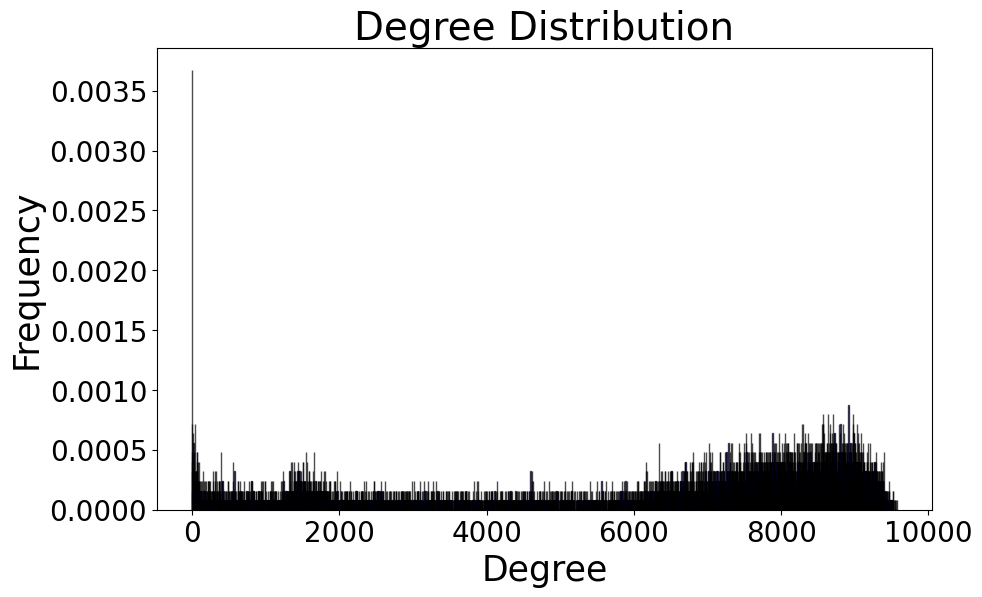

Number of clusters: 364

IOStream.flush timed out
IOStream.flush timed out



Cluster assignments: [24, 8, 3, 1, 5, 2, 1, 3, 4, 8, 0, 2, 0, 0, 0, 7, 46, 4, 6, 14]
Number of modules: 119


In [42]:
# set the resolution parameter to 0.6 in this case (feel free to tweak a bit)
module_I = distance_to_module_nlog(distance_coordinate=distance_I, fig_path1="./figures/degree_distribution_I.svg", fig_path2="./figures/weight_distribution_I.svg", threshold_percentile=50, resolution_parameter=0.6, seed=123456)
module_to_json(module_dict=module_I, file_path="module_I.json")

threshold_percentile = 50%: threshold_distance = 469.2459409638665
Number of connected components: 34


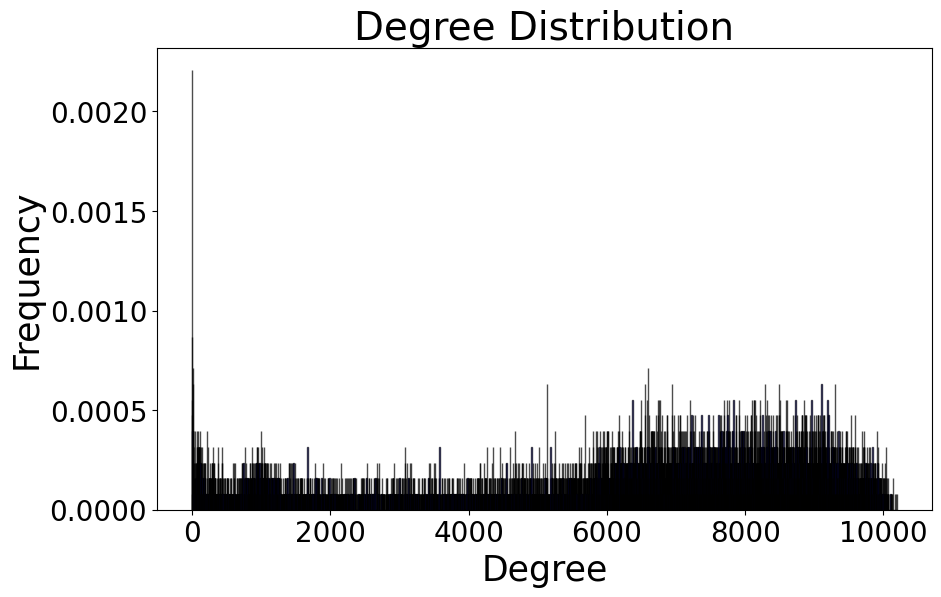

Number of clusters: 309
Cluster assignments: [8, 16, 0, 0, 5, 2, 0, 0, 71, 0, 0, 6, 1, 0, 2, 3, 0, 10, 2, 7]
Number of modules: 124


In [14]:
module_IV = distance_to_module_nlog(distance_coordinate=distance_IV, fig_path1="./figures/degree_distribution_IV.svg", fig_path2="./figures/weight_distribution_IV.svg", threshold_percentile=50, resolution_parameter=0.6, seed=123456)
module_to_json(module_dict=module_IV, file_path="module_IV.json")

In [43]:
print(len(module_I))
print(len(module_IV))

119
124


### BRIDGE

In [59]:
module_I = module_to_dict("module_I.json")
module_IV = module_to_dict("module_IV.json")

In [60]:
module_relation_bipartite(q_value=0.001, first_module=module_I, second_module=module_IV, first_module_stage="I", second_module_stage="IV", save=True)

In [52]:
module_I_vs_IV_relation = Graph.Read_GraphML("module_I_vs_IV_relation.graphml")

In [53]:
mutual_nodes = find_all_transition_set(first_stage_module=module_I, second_stage_module=module_IV, relation_graph=module_I_vs_IV_relation, first_pcc_matrix=pcc_I, second_pcc_matrix=pcc_IV, pcc_theshold=0.5)
print(len(mutual_nodes))

587


In [61]:
transition_set_I_vs_IV = file_to_string(file="transition_set_I_vs_IV.txt")

In [62]:
DEG_IV_I = file_to_string(file="../../results/Cell/deg_IV_I.txt")

In [66]:
targets_IV_I = find_targets(DEG=DEG_IV_I, transition_set=transition_set_I_vs_IV)

In [67]:
target_genes = dict(
    # targets_I_4S=targets_I_4S,
    # targets_III_4S=targets_III_4S,
    # targets_IV_4S=targets_IV_4S,
    # targets_III_I=targets_III_I,
    targets_IV_I=targets_IV_I,
    # targets_IV_III=targets_IV_III
    )

In [68]:
module_to_json(module_dict=target_genes, file_path="target_genes.json")